# CBF Results

Build the CBF cross-seed LaTeX table and saved-data plots. This notebook does not evaluate networks again.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.base.result import BaseResult
from src.scenarios.cbf.system import System
from src.scenarios.cbf.visualization import Visualization
from src.utils.config import Config
from src.utils.result import build_average_table, discover_seeds

torch.set_default_dtype(torch.float64)

RESULT_ROOT = REPO_ROOT / "results" / "cbf"
print("Available runs:", sorted(path.name for path in RESULT_ROOT.glob("*") if path.is_dir()))

DIR_NAME = "final"
RUN_DIR = RESULT_ROOT / DIR_NAME
OUTPUT_DIR = RUN_DIR

METHODS = ["NN", "HardNet", "CAffNet-FF"]
AVAILABLE_SEEDS = discover_seeds(RUN_DIR)
SEEDS = [
    seed
    for seed in AVAILABLE_SEEDS
    if all(
        (RUN_DIR / f"seed_{seed}" / method / "evaluation.csv").exists()
        or (RUN_DIR / f"seed_{seed}" / f"{method}_evaluation.csv").exists()
        for method in METHODS
    )
]
SKIPPED_SEEDS = sorted(set(AVAILABLE_SEEDS).difference(SEEDS))

print("Using seeds:", SEEDS)
print("Skipped incomplete seeds:", SKIPPED_SEEDS)

PLOT_SEED = 10 if 10 in SEEDS else SEEDS[0]
RUN_DIR

Available runs: ['final']
Using seeds: [2, 7, 10, 11]
Skipped incomplete seeds: [6]


PosixPath('/Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/cbf/final')

## Average Table Across Seeds

In [2]:
table = build_average_table(
    RUN_DIR,
    SEEDS,
    METHODS,
    OUTPUT_DIR,
    metric_rename={
        "Max ineq viol.": ("Ineq viol.", "Max"),
        "Mean ineq viol.": ("Ineq viol.", "Mean"),
        "Num ineq viol. (%)": ("Ineq viol.", "Num (%)"),
    },
    column_rename={"Ineq viol.": "Inequality violation"},
    bold_best=True,
)
table

[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/cbf/final/seed_2
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/cbf/final/seed_7
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/cbf/final/seed_10
[INFO] Processing /Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/cbf/final/seed_11
\begin{tabular}{lcccccc}
\toprule
Method & Cost & \multicolumn{3}{c}{Inequality violation} & $T_{test}$ (ms) & $T_{train}$ (ms) \\
\cmidrule(lr){3-5}
 &  & Max & Mean & Num (\%) &  &  \\
\midrule
NN & \textbf{421241.1970} & 0.1304 & 0.0103 & 2.60\% & \textbf{43.5200} & \textbf{2884.1600} \\
 & (33584.5414) & (0.0072) & (0.0005) & (0.04\%) & (3.58) & (147.97) \\
HardNet & 457472.1347 & 0.1328 & 0.0105 & 2.60\% & 112

Method                  Cost Inequality violation                   \
                                                     Max             Mean   
0          NN  \textbf{421241.1970}               0.1304           0.0103   
1                      (33584.5414)             (0.0072)         (0.0005)   
2     HardNet           457472.1347               0.1328           0.0105   
3                      (40451.0533)             (0.0043)         (0.0003)   
4  CAffNet-FF           910758.8227      \textbf{0.0000}  \textbf{0.0000}   
5                     (232144.3152)             (0.0000)         (0.0000)   

             $T_{test}$ (ms)    $T_{train}$ (ms)  
   Num (%)                                        
0    2.60%  \textbf{43.5200}  \textbf{2884.1600}  
1  (0.04%)            (3.58)            (147.97)  
2    2.60%         1127.5300           5114.6700  
3  (0.04%)          (104.60)             (90.10)  
4    0.00%         1567.6500          12071.0900  
5  (0.00%)           (11.32)            (241.53)

Saved outputs:

- `evaluation_all_seeds.csv`
- `evaluation_all_seeds.tex`

## Load Plot Seed Config And Visualization

In [3]:
seed_dir = RUN_DIR / f"seed_{PLOT_SEED}"
scenario_cfg_path = REPO_ROOT / "src" / "scenarios" / "cbf" / "cfg.yaml"
cfg_path = seed_dir / "cfg.yaml"
if not cfg_path.exists():
    cfg_path = scenario_cfg_path

cfg = Config().load(cfg_path)
cfg.visualization = Config().load(scenario_cfg_path).visualization
cfg.result_dir = str(seed_dir)
cfg.simulation.seed = PLOT_SEED

random.seed(PLOT_SEED)
np.random.seed(PLOT_SEED)
torch.manual_seed(PLOT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(PLOT_SEED)
    torch.cuda.manual_seed_all(PLOT_SEED)

system = System(cfg)
visualization = Visualization(cfg, system, system.constraint)
result = BaseResult(cfg, visualization)

seed_dir

PosixPath('/Users/zhao.yang12/Desktop/Projects/202506_SafeAI/code/CAffNet-Hard-Constraint-Affine-Neural-Networks/results/cbf/final/seed_10')

## Result Plot From Plot Seed

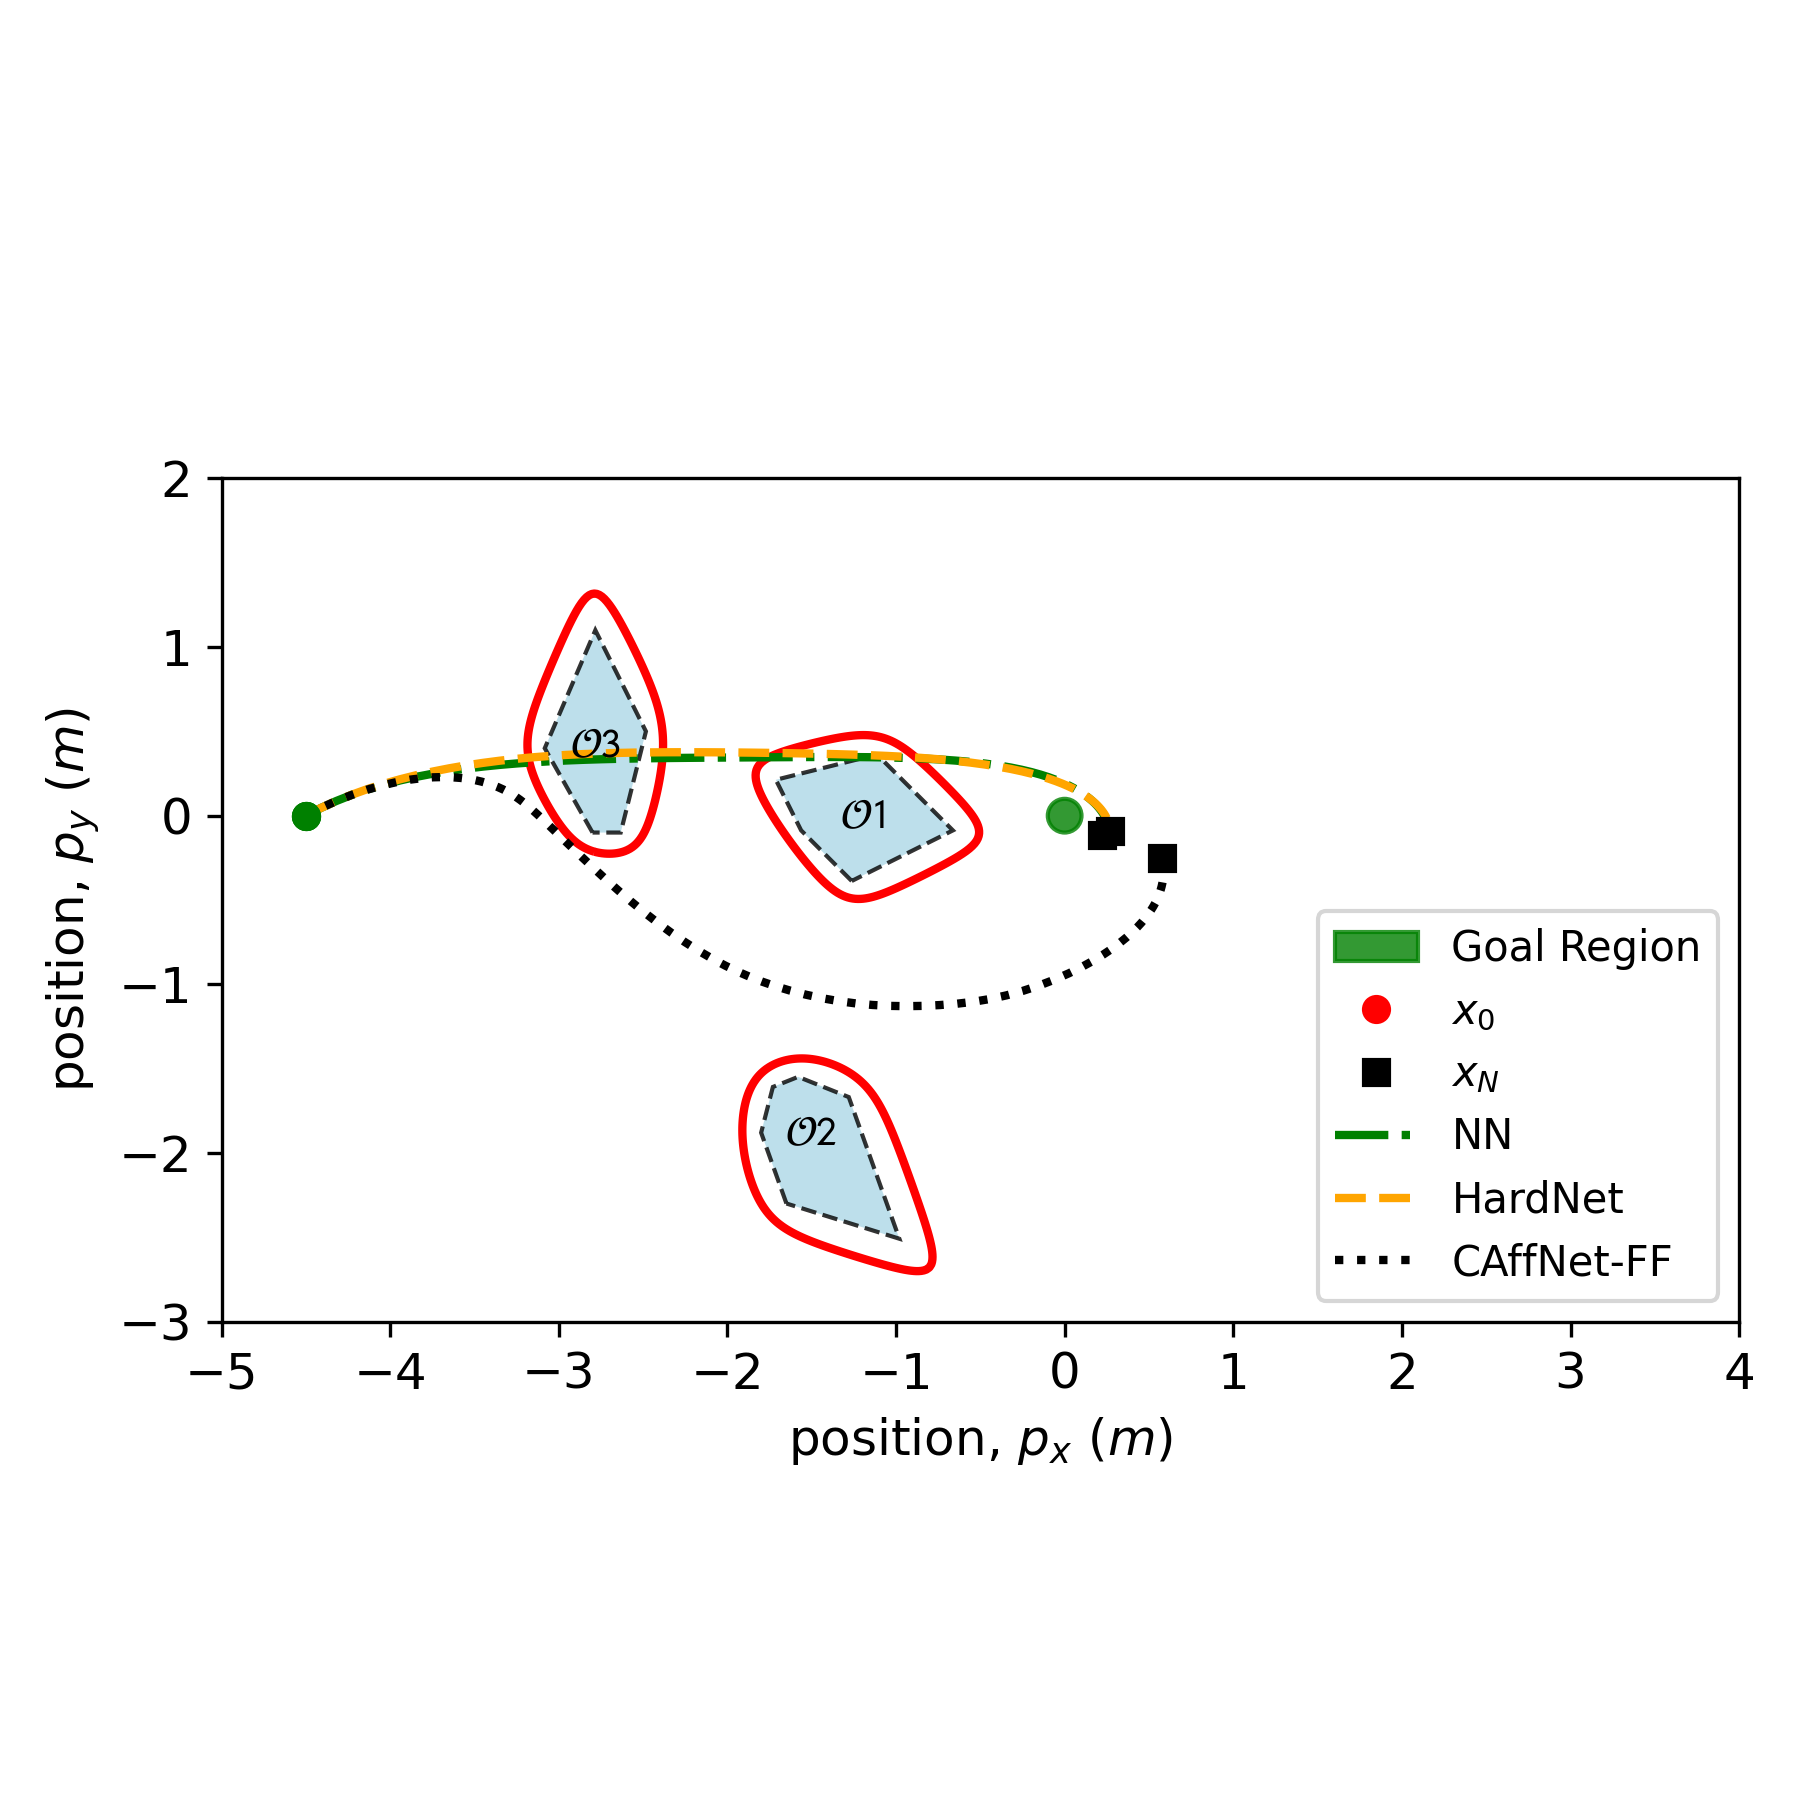

In [4]:
result_png = f"result_seed_{PLOT_SEED}.png"
fig, _ = result.plot_results(METHODS, filename=result_png, output_dir=OUTPUT_DIR, show_plot=False)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / result_png)))

## Control Plots From Plot Seed

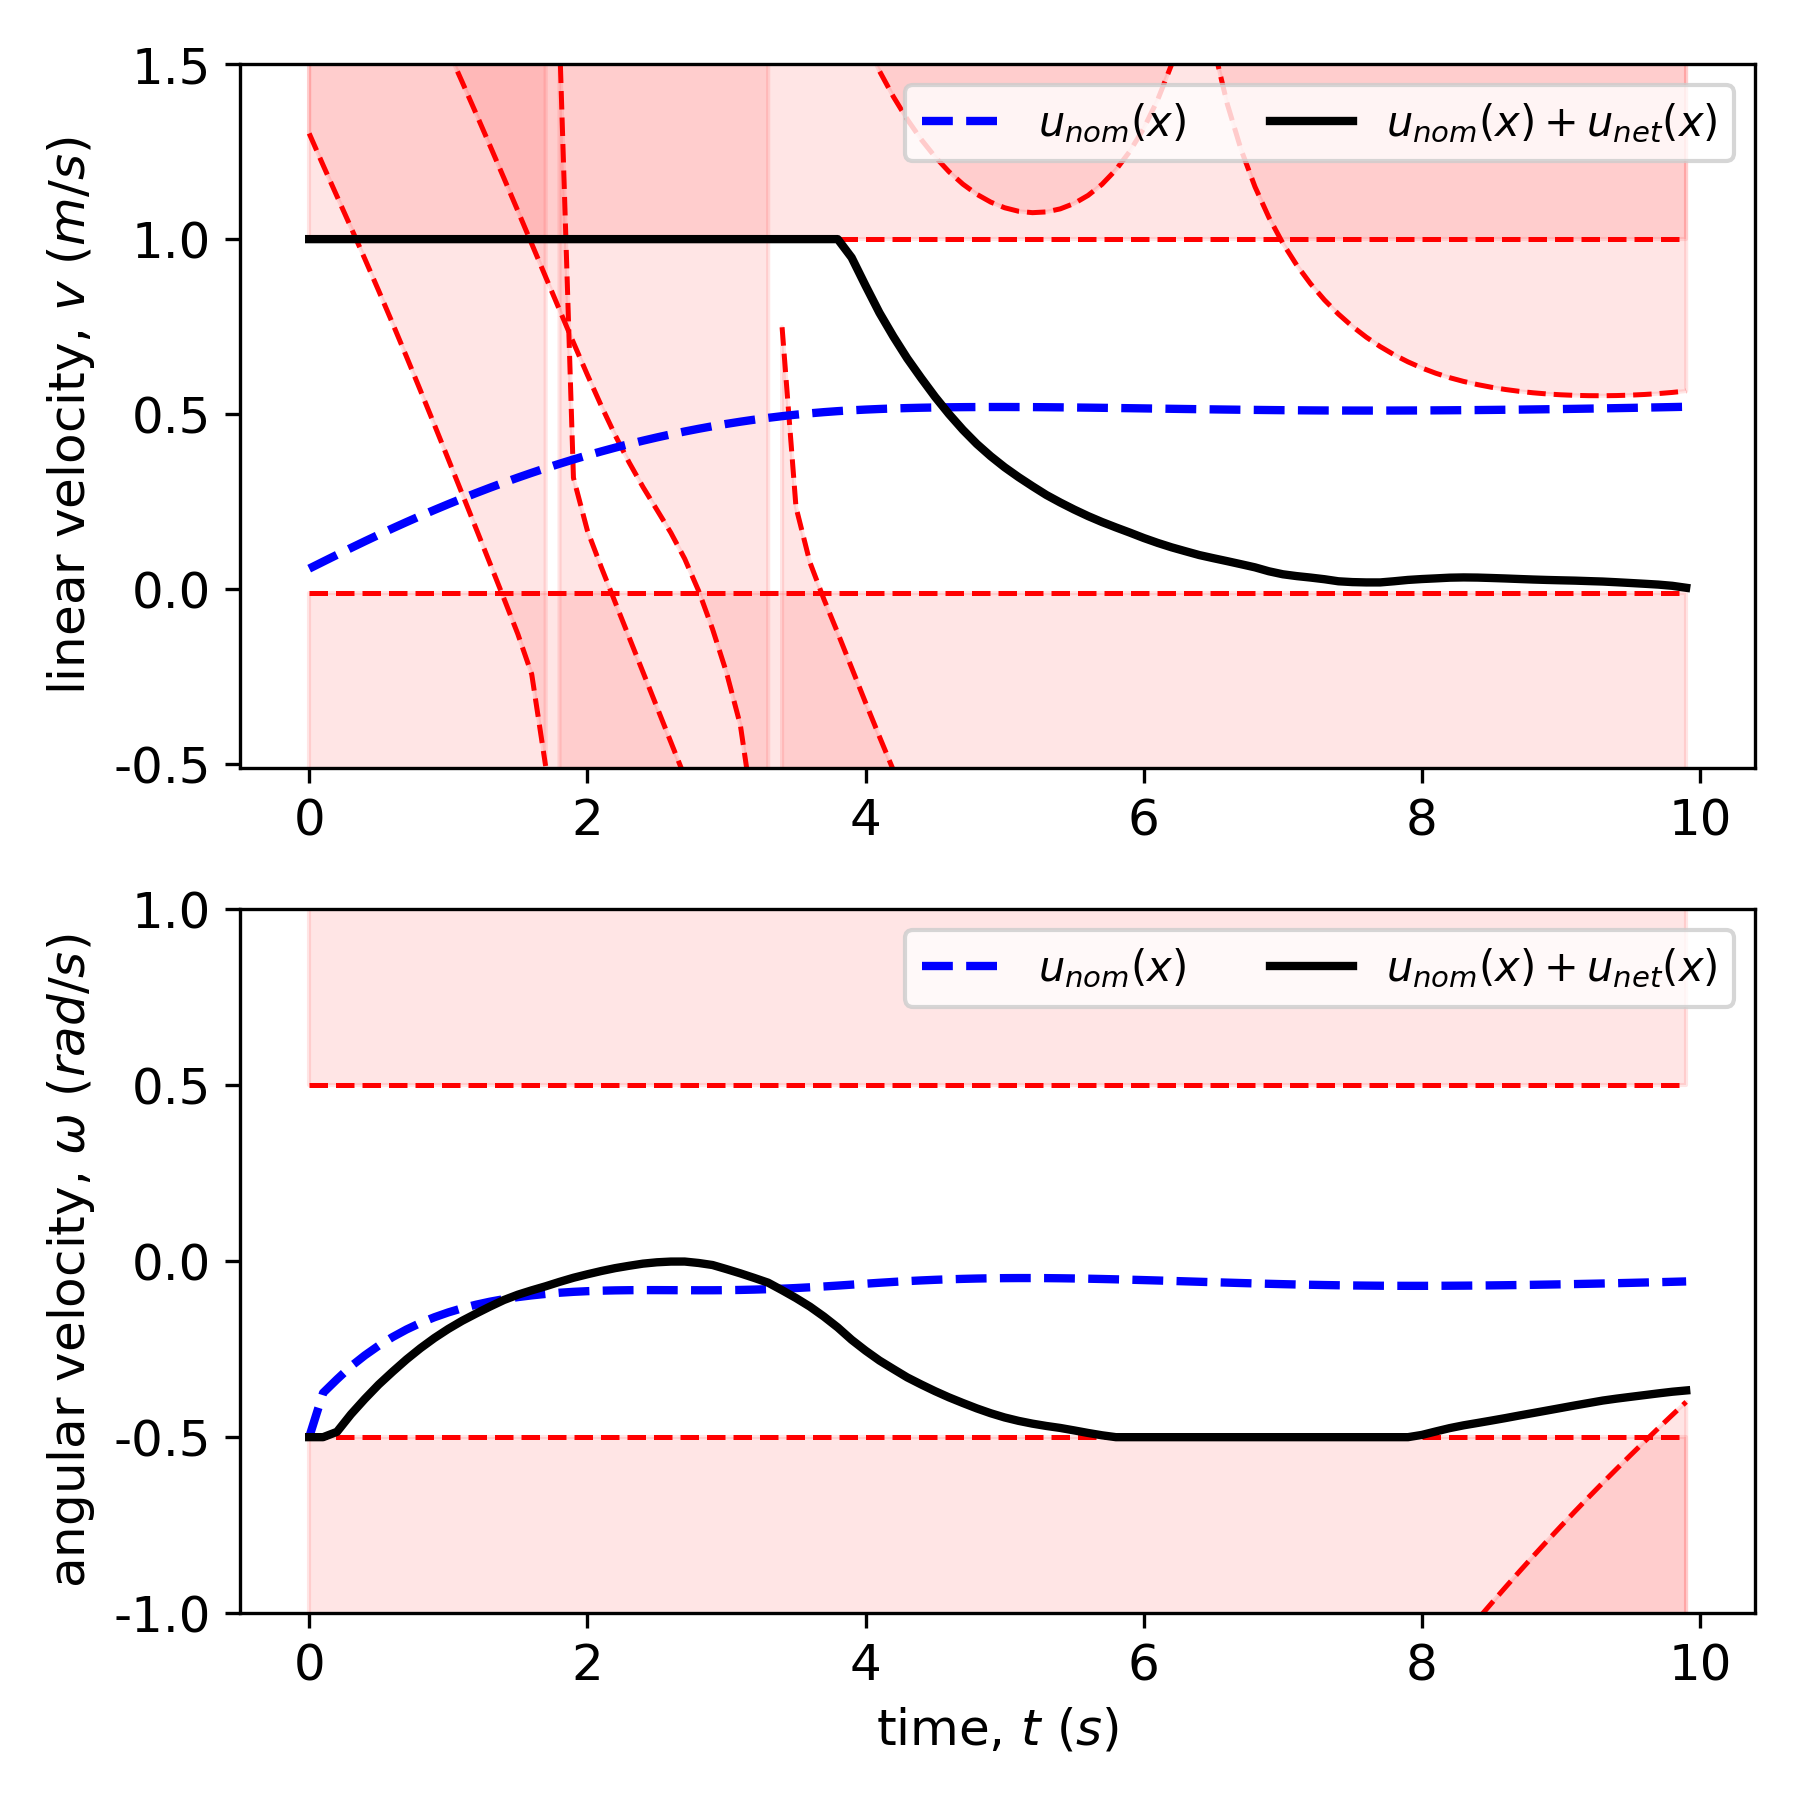

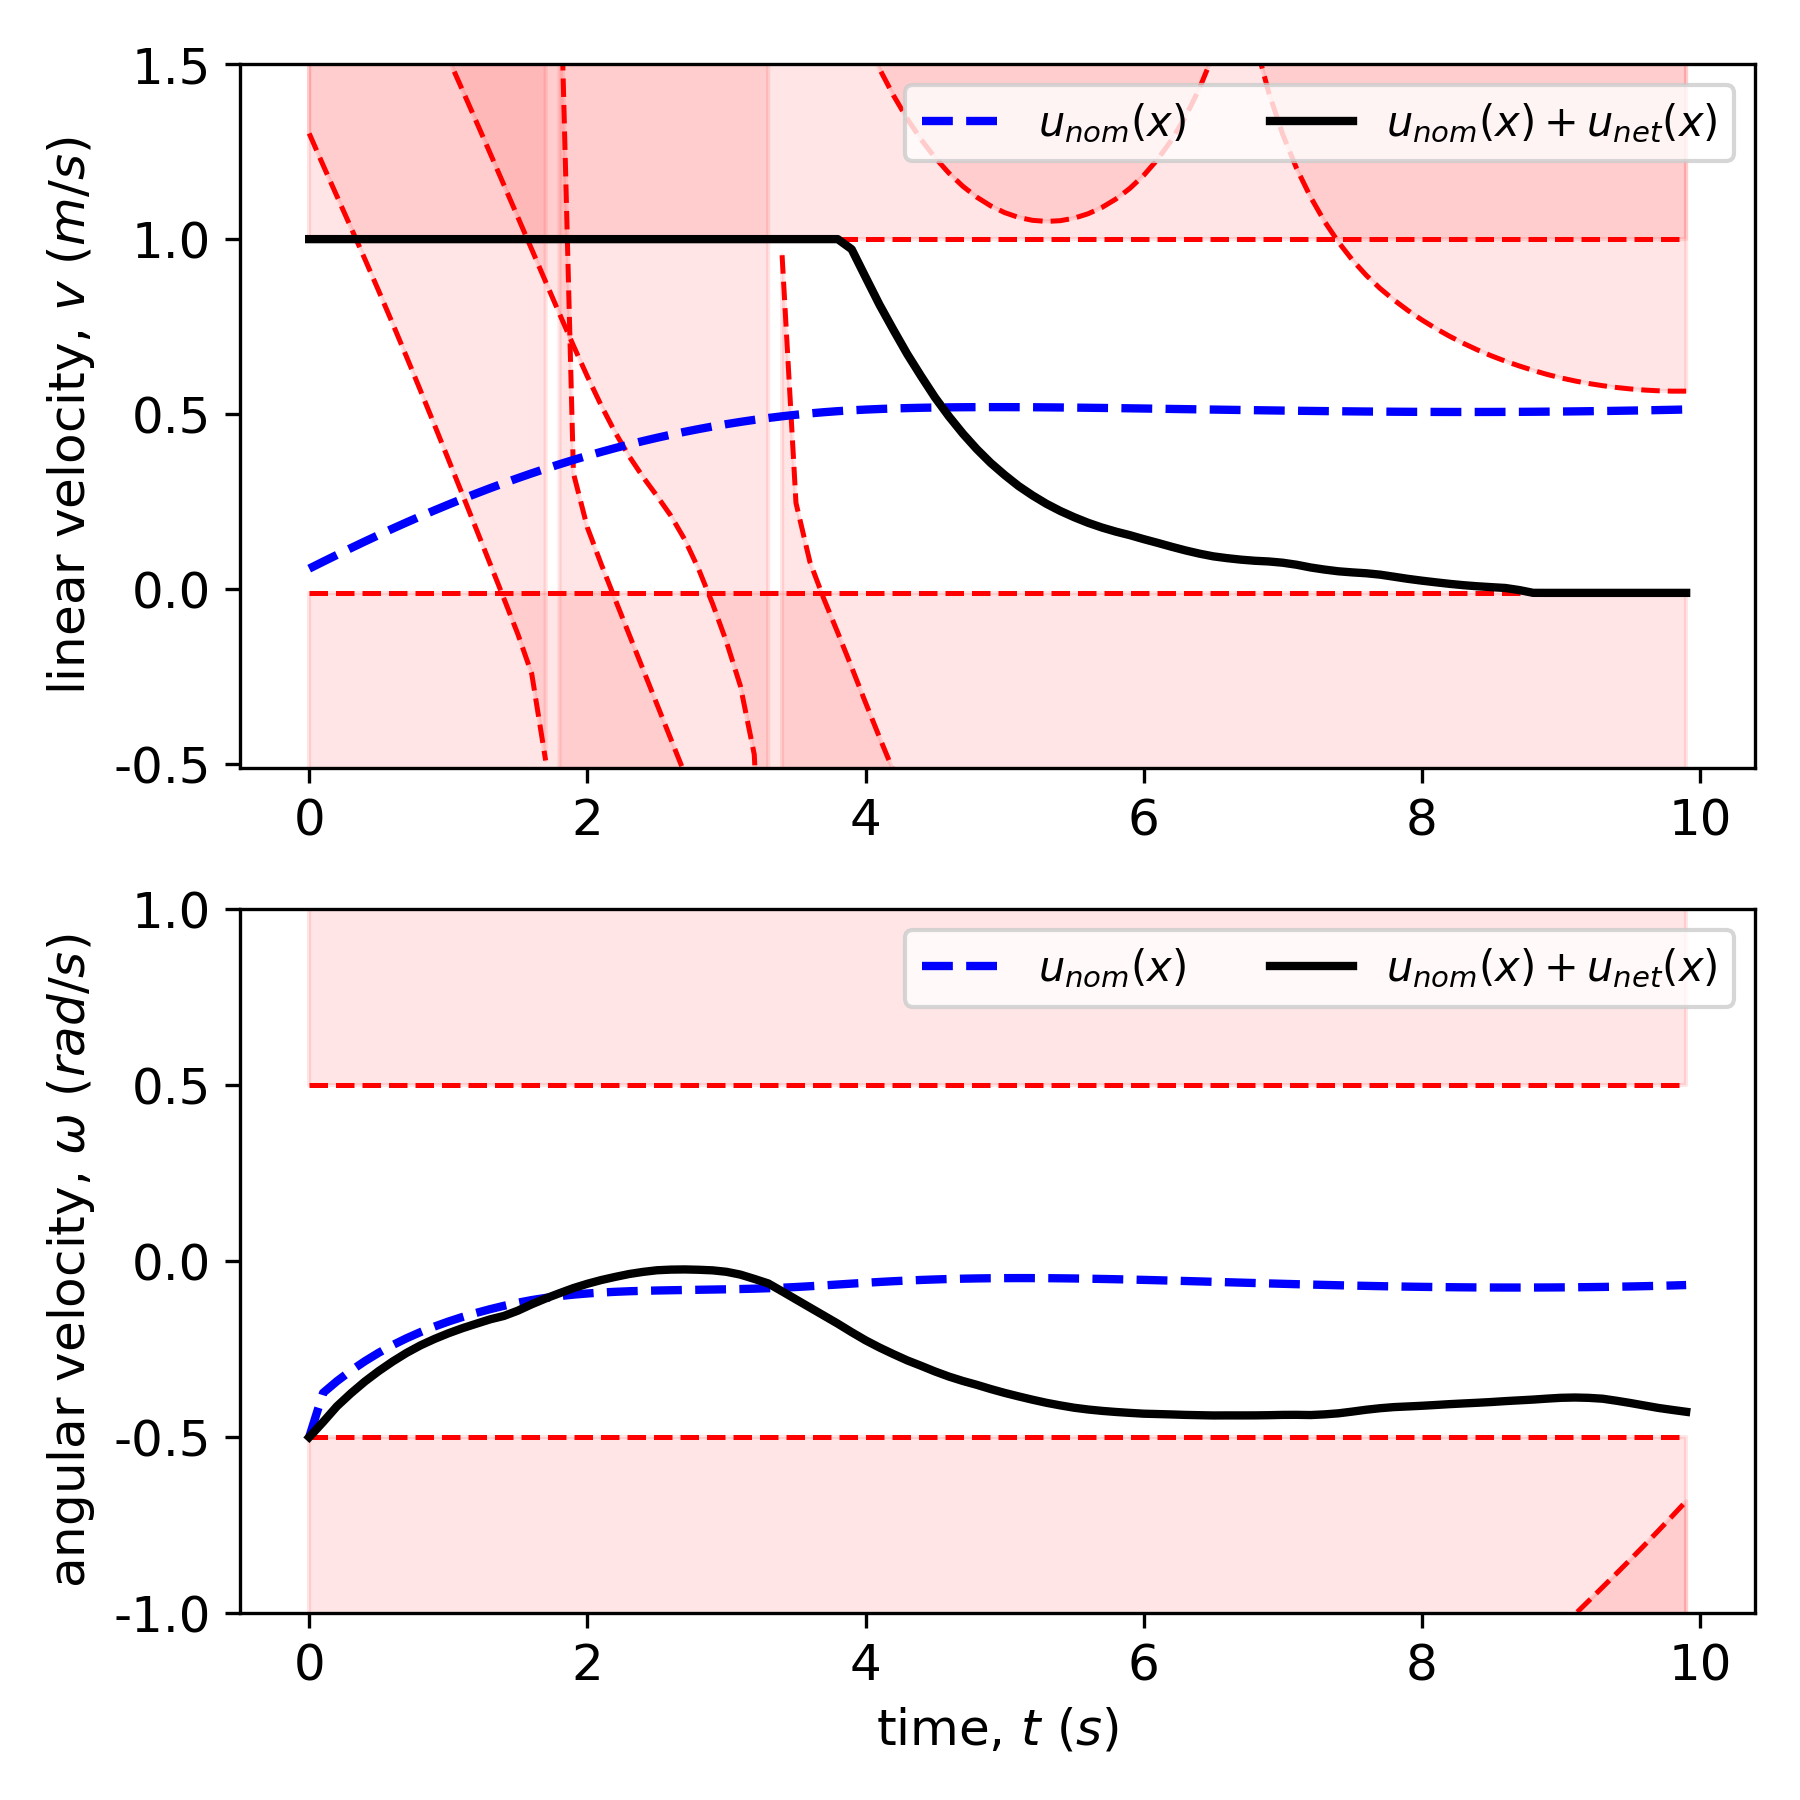

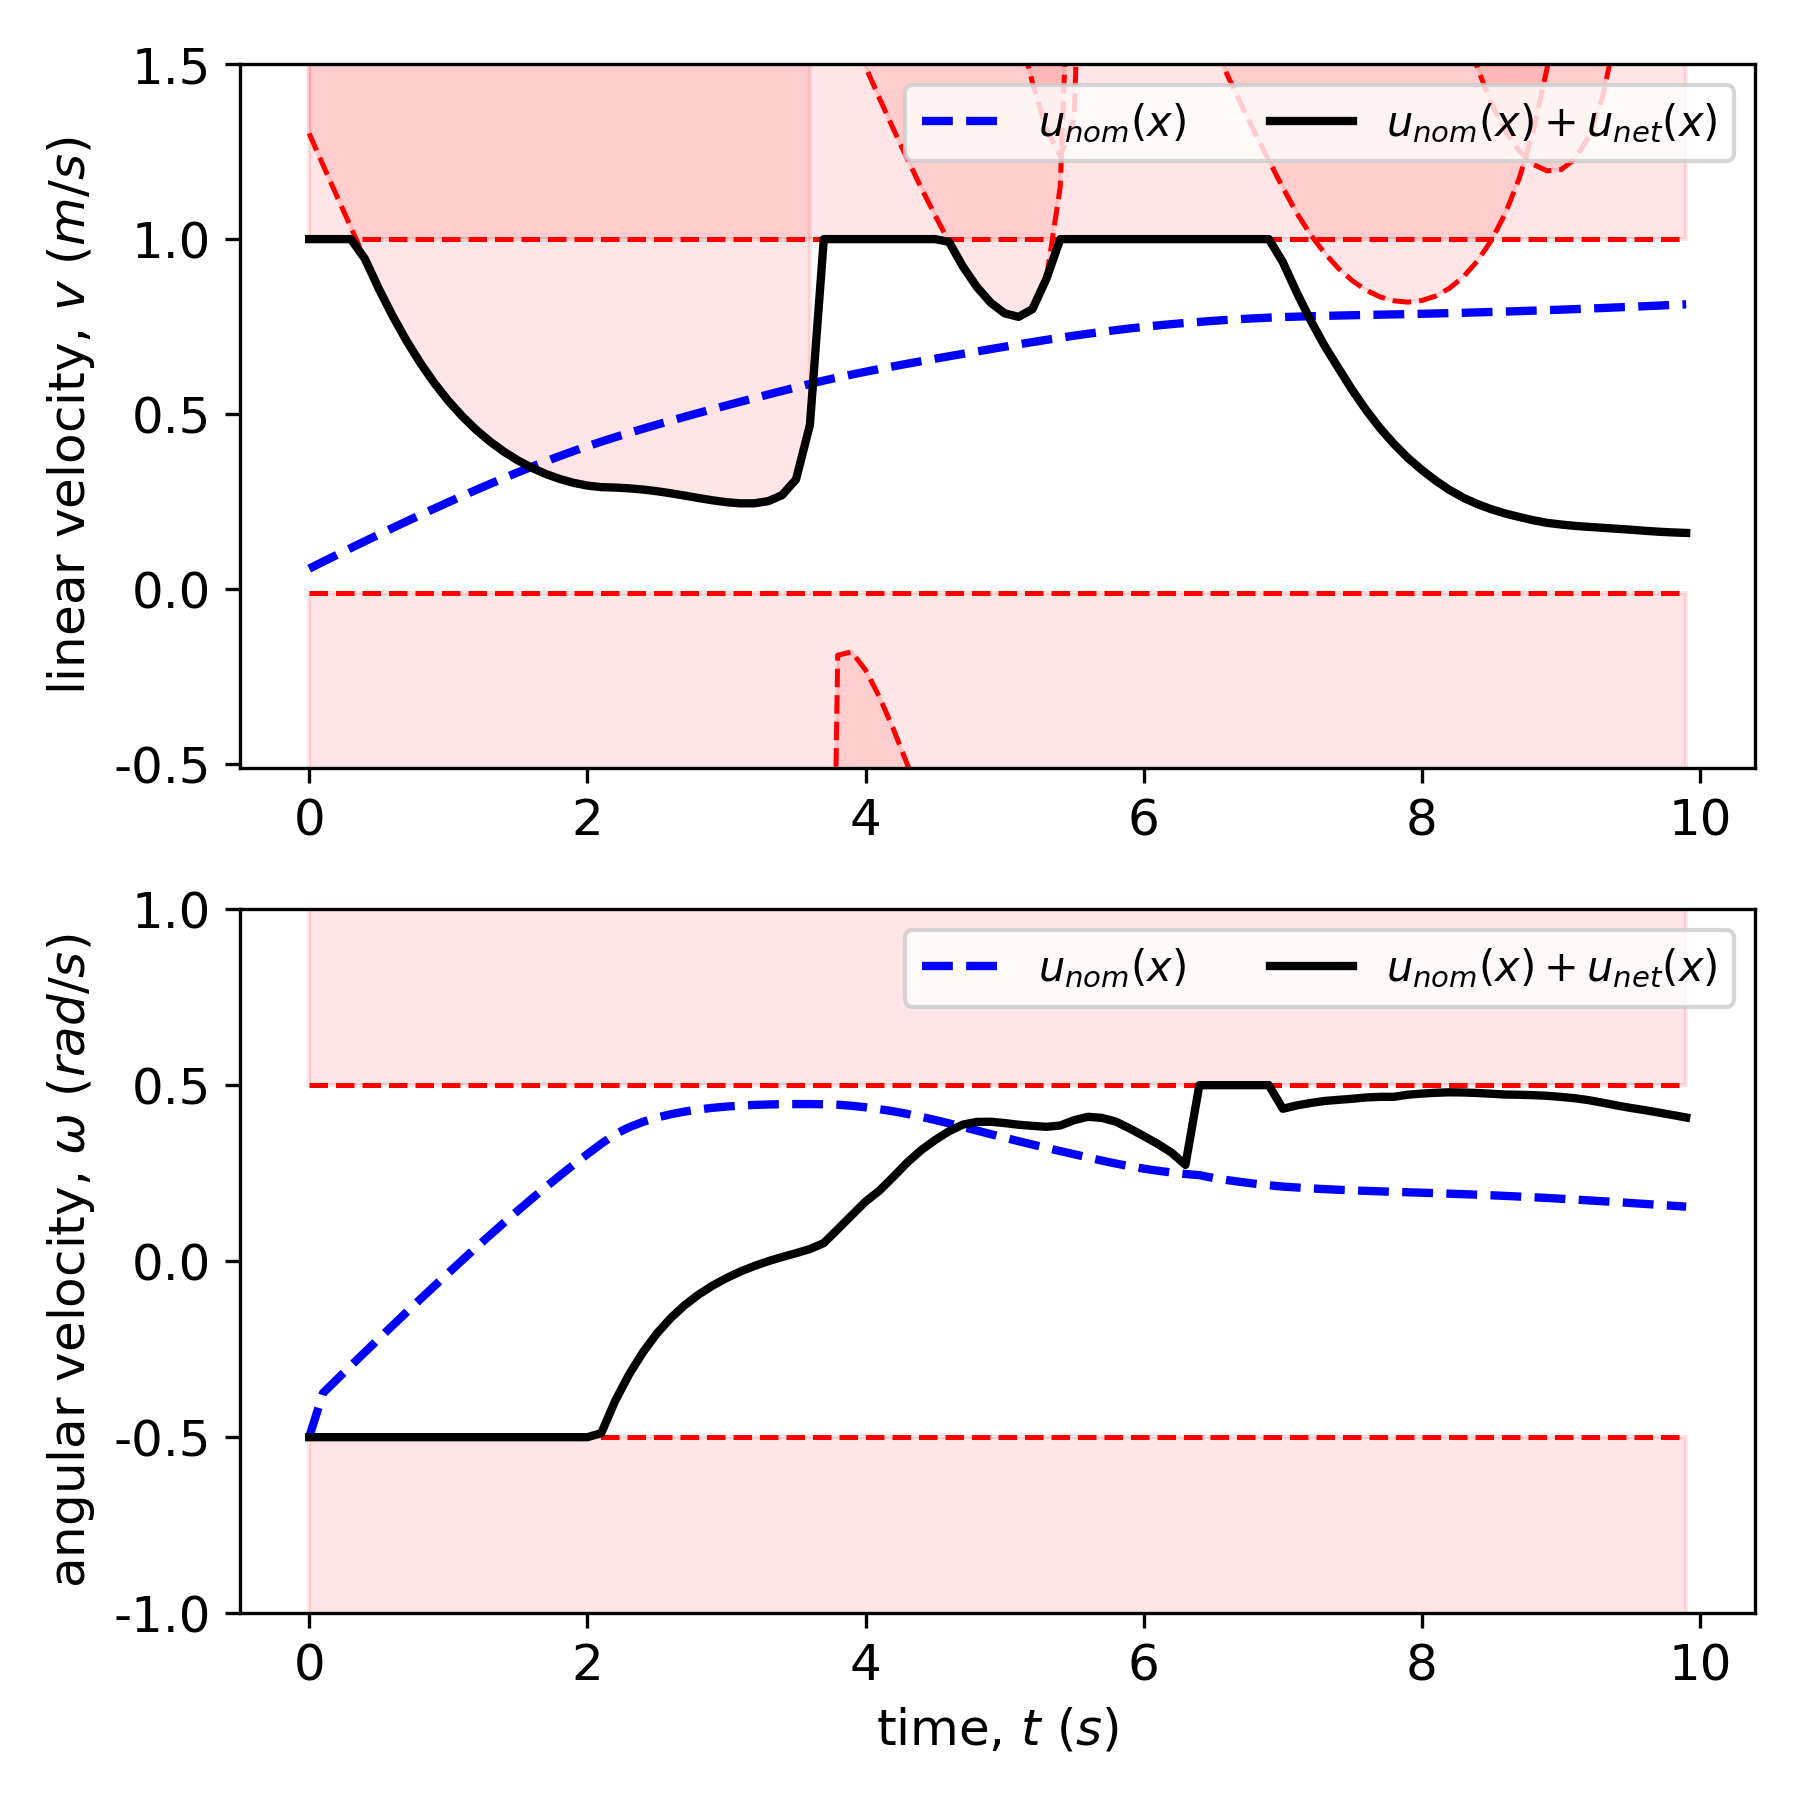

In [5]:
for method in METHODS:
    control_png = f"{method}_u_seed_{PLOT_SEED}.png"
    data = result.load_result_data(method)
    fig, _ = visualization.plot_control(data, show_plot=False)
    fig.savefig(OUTPUT_DIR / control_png)
    plt.close(fig)
    display(Image(filename=str(OUTPUT_DIR / control_png)))

## Loss Plot From Plot Seed

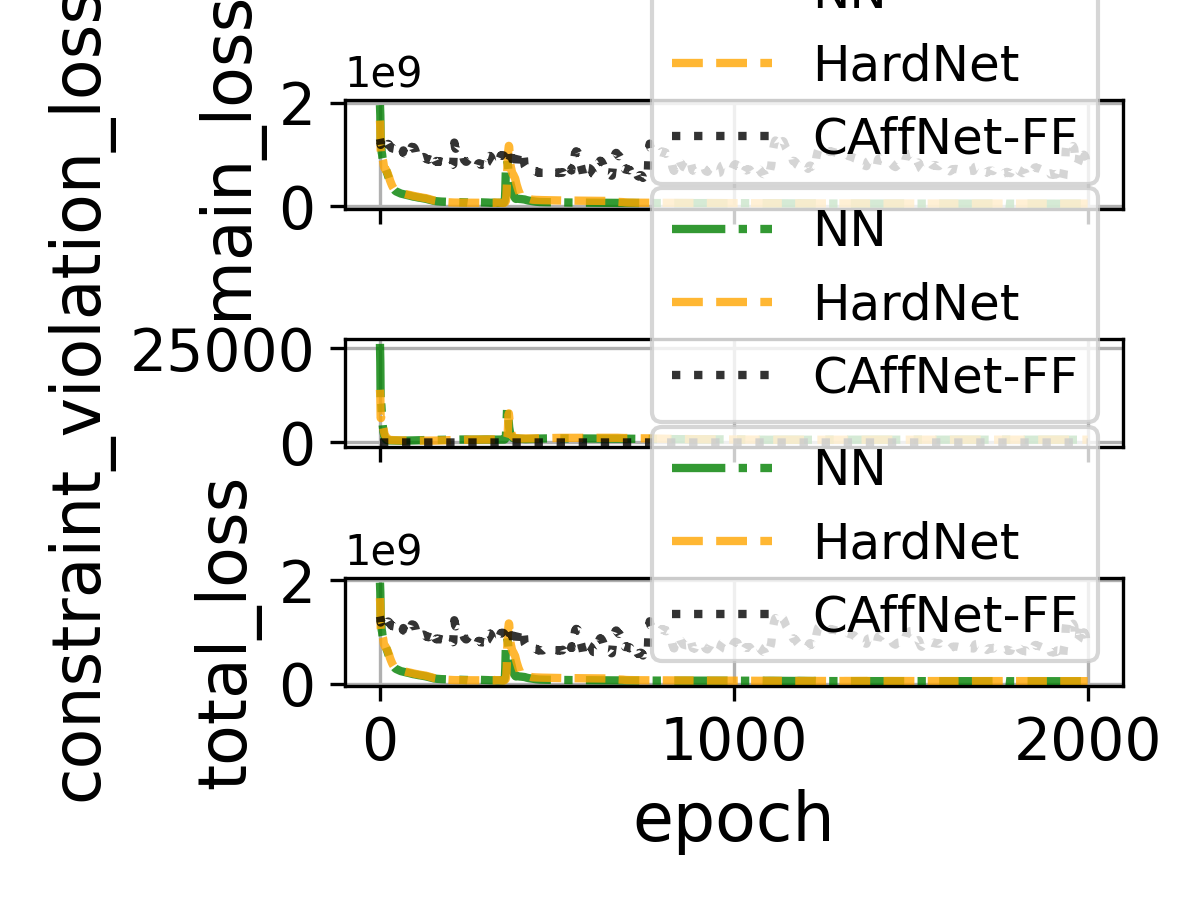

In [6]:
loss_png = f"loss_seed_{PLOT_SEED}.png"
fig, _ = result.plot_loss(METHODS, filename=loss_png, output_dir=OUTPUT_DIR, show_plot=False)
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / loss_png)))